# 01 — Exploración inicial (Lending Club)

**Proyecto final de Machine Learning — Entrega previa**

Predicción de incumplimiento de préstamos usando solo información disponible en
el momento de la decisión crediticia.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [22]:
from pathlib import Path

TARGET = "mal_desempeno"
FIG = Path("reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

## 1. Carga y exploración inicial

In [23]:
import random

DATA_PATH = "accepted_2007_to_2018Q4.csv"

columnas_utiles = [
    'loan_status', 'issue_d',
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'purpose', 'application_type', 'initial_list_status',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'dti',
    'fico_range_low', 'fico_range_high', 'earliest_cr_line', 'open_acc',
    'revol_util', 'revol_bal', 'total_acc', 'delinq_2yrs', 'inq_last_6mths',
    'pub_rec', 'pub_rec_bankruptcies',
]

random.seed(RANDOM_SEED)
FRAC = 0.08
df = pd.read_csv(DATA_PATH, usecols=columnas_utiles, low_memory=False,
                 skiprows=lambda i: i > 0 and random.random() > FRAC)
df = df.dropna(subset=["loan_status"])

print(f"Filas cargadas: {df.shape[0]:,}")
print(f"Columnas cargadas: {df.shape[1]}")
df.head()

Filas cargadas: 163,818
Columnas cargadas: 27


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,pub_rec_bankruptcies
0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,small_business,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,Individual,0.0
1,8000.0,36 months,11.48,263.74,B,B5,10+ years,MORTGAGE,42000.0,Not Verified,Dec-2015,Fully Paid,credit_card,34.80,0.0,Nov-1994,700.0,704.0,0.0,8.0,0.0,7034.0,39.1,18.0,w,Individual,0.0
2,1400.0,36 months,12.88,47.10,C,C2,3 years,MORTGAGE,64000.0,Not Verified,Dec-2015,Fully Paid,other,34.95,0.0,Jun-1996,700.0,704.0,0.0,17.0,0.0,37828.0,67.2,24.0,w,Individual,0.0
3,8650.0,36 months,19.89,320.99,E,E3,8 years,RENT,55000.0,Verified,Dec-2015,Fully Paid,debt_consolidation,25.49,0.0,Mar-2005,675.0,679.0,4.0,18.0,1.0,9568.0,46.0,19.0,w,Individual,1.0
4,10000.0,60 months,17.97,253.78,D,D4,2 years,MORTGAGE,55000.0,Not Verified,Dec-2015,Charged Off,credit_card,35.70,0.0,Apr-2001,685.0,689.0,0.0,14.0,0.0,38623.0,78.0,28.0,w,Individual,0.0


## Número de filas, columnas y tipos de datos

In [24]:
n_filas, n_columnas = df.shape
print(f"Filas: {n_filas:,}")
print(f"Columnas: {n_columnas}")

df.info(verbose=True, show_counts=True)

Filas: 163,818
Columnas: 27
<class 'pandas.core.frame.DataFrame'>
Index: 163818 entries, 0 to 163822
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             163818 non-null  float64
 1   term                  163818 non-null  object 
 2   int_rate              163818 non-null  float64
 3   installment           163818 non-null  float64
 4   grade                 163818 non-null  object 
 5   sub_grade             163818 non-null  object 
 6   emp_length            153367 non-null  object 
 7   home_ownership        163818 non-null  object 
 8   annual_inc            163816 non-null  float64
 9   verification_status   163818 non-null  object 
 10  issue_d               163818 non-null  object 
 11  loan_status           163818 non-null  object 
 12  purpose               163818 non-null  object 
 13  dti                   163714 non-null  float64
 14  delinq_2yrs           163816 

In [25]:
tipos = df.dtypes.value_counts()
tipos

,count
float64,15
object,12


## Porcentaje de valores faltantes por variable

In [26]:
faltantes = df.isna().mean().sort_values(ascending=False) * 100
faltantes = faltantes[faltantes > 0]

print(f"Variables con al menos un valor faltante: {len(faltantes)} de {df.shape[1]}")
faltantes

Variables con al menos un valor faltante: 11 de 27


,0
emp_length,6.379641
revol_util,0.075083
pub_rec_bankruptcies,0.070810
dti,0.063485
earliest_cr_line,0.001221
pub_rec,0.001221
open_acc,0.001221
delinq_2yrs,0.001221
inq_last_6mths,0.001221
annual_inc,0.001221


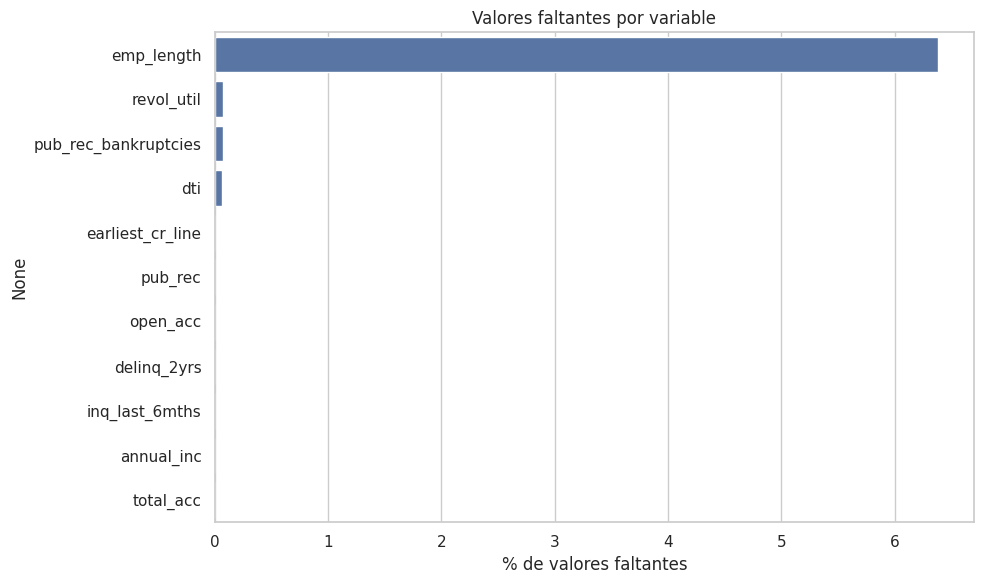

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(x=faltantes.values, y=faltantes.index, color="#4C72B0")
plt.xlabel("% de valores faltantes")
plt.title("Valores faltantes por variable")
plt.tight_layout()
plt.show()

- `emp_length` es la única variable con un nivel relevante de faltantes (**6.38%**).
  Esto puede deberse a que el solicitante no reportó su antigüedad laboral o a
  que corresponde a un tipo de empleo no estándar.
- El resto de variables (`revol_util`, `pub_rec_bankruptcies`, `dti` y otras) tiene
  menos de **0.08%** de faltantes, un nivel bajo que puede tratarse con imputación
  simple (mediana/moda) dentro del `Pipeline`.
- No se observa un patrón de "faltantes masivos" que obligue a descartar columnas.

## 2. Distribución de la variable objetivo

In [28]:
df['loan_status'].value_counts(dropna=False)

,count
loan_status,
Fully Paid,80504
Current,60839
Charged Off,20027
Late (31-120 days),1410
In Grace Period,552
Late (16-30 days),268
Does not meet the credit policy. Status:Fully Paid,154
Does not meet the credit policy. Status:Charged Off,63
Default,1


In [29]:
malos = [
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off',
]
buenos = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid',
]

estados_validos = malos + buenos
df = df[df['loan_status'].isin(estados_validos)].copy()
df['mal_desempeno'] = df['loan_status'].isin(malos).astype(int)

print(f"Filas con target definido: {df.shape[0]:,}")
df['mal_desempeno'].value_counts(normalize=True) * 100

Filas con target definido: 102,159


,proportion
mal_desempeno,
0,78.953396
1,21.046604


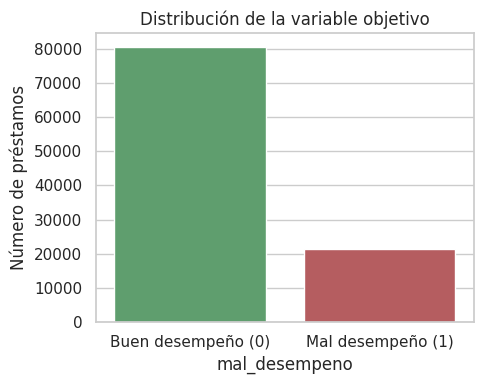

In [30]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='mal_desempeno', hue='mal_desempeno',
              palette={0: "#55A868", 1: "#C44E52"}, legend=False)
plt.xticks([0, 1], ["Buen desempeño (0)", "Mal desempeño (1)"])
plt.ylabel("Número de préstamos")
plt.title("Distribución de la variable objetivo")
plt.tight_layout()
plt.show()

- Tras excluir los préstamos no resueltos (`Current`, `In Grace Period`,
  `Late (16-30 days)`), quedan **102 159 préstamos**: **78.95%** con buen desempeño (0)
  y **21.05%** con mal desempeño/default (1). Es un desbalance moderado.
- Accuracy no es adecuada: predecir siempre "buen desempeño" daría ~79% de acierto
  sin aprender nada. Por eso se usa **ROC-AUC** como métrica principal y **PR-AUC**
  y **KS** como secundarias.
- El manejo del desbalance (`class_weight`, resampling o ajuste de umbral) se evaluará
  en la fase de modelado; el baseline se entrena **sin balanceo**.

## 3. Visualizaciones relevantes

Seis vistas centradas en la relación de las variables de originación con el
riesgo de default.

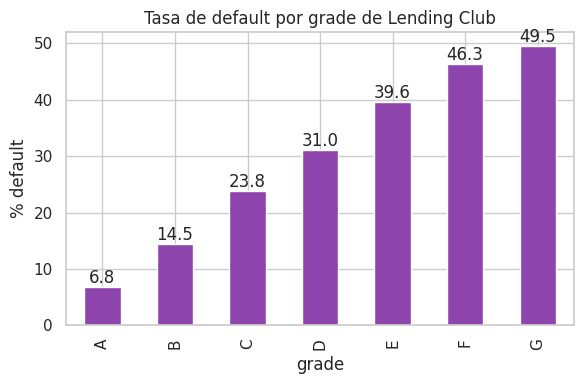

In [31]:
# 3.1 Tasa de default por grado de riesgo (grade)
if "grade" in df.columns:
    g = (df.groupby("grade")[TARGET].mean().sort_index()*100)
    fig, ax = plt.subplots(figsize=(6,4))
    g.plot.bar(ax=ax, color="#8e44ad")
    ax.set_title("Tasa de default por grade de Lending Club")
    ax.set_ylabel("% default"); ax.set_xlabel("grade")
    for c in ax.containers: ax.bar_label(c, fmt="%.1f")
    fig.tight_layout(); fig.savefig(FIG/"03_default_by_grade.png", dpi=120); plt.show()

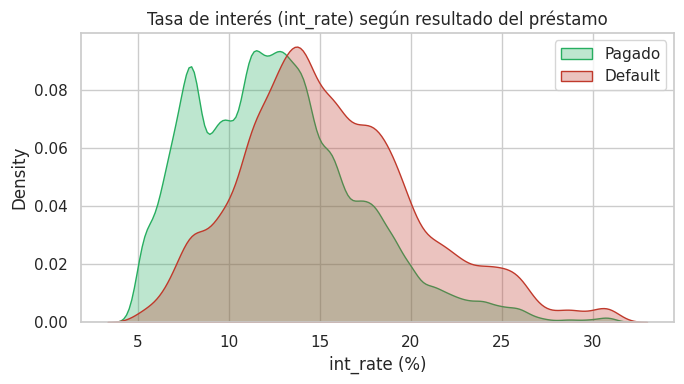

In [32]:
# 3.2 Distribución de int_rate segun resultado
if "int_rate" in df.columns:
    fig, ax = plt.subplots(figsize=(7,4))
    for k, lbl, col in [(0,"Pagado","#27ae60"),(1,"Default","#c0392b")]:
        sub = df.loc[df[TARGET]==k, "int_rate"].dropna()
        sns.kdeplot(sub, ax=ax, label=lbl, fill=True, alpha=.3, color=col)
    ax.set_title("Tasa de interés (int_rate) según resultado del préstamo")
    ax.set_xlabel("int_rate (%)"); ax.legend()
    fig.tight_layout(); fig.savefig(FIG/"04_intrate_by_target.png", dpi=120); plt.show()

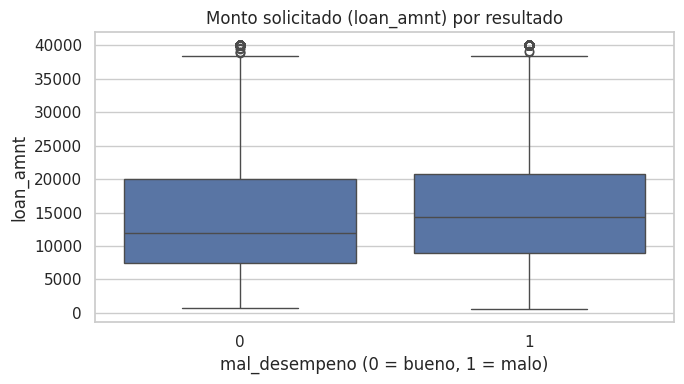

In [33]:
# 3.3 Distribución del monto solicitado por resultado
if "loan_amnt" in df.columns:
    fig, ax = plt.subplots(figsize=(7,4))
    sns.boxplot(data=df, x=TARGET, y="loan_amnt", ax=ax)
    ax.set_title("Monto solicitado (loan_amnt) por resultado")
    ax.set_xlabel("mal_desempeno (0 = bueno, 1 = malo)"); ax.set_ylabel("loan_amnt")
    fig.tight_layout(); fig.savefig(FIG/"05_loanamnt_by_target.png", dpi=120); plt.show()

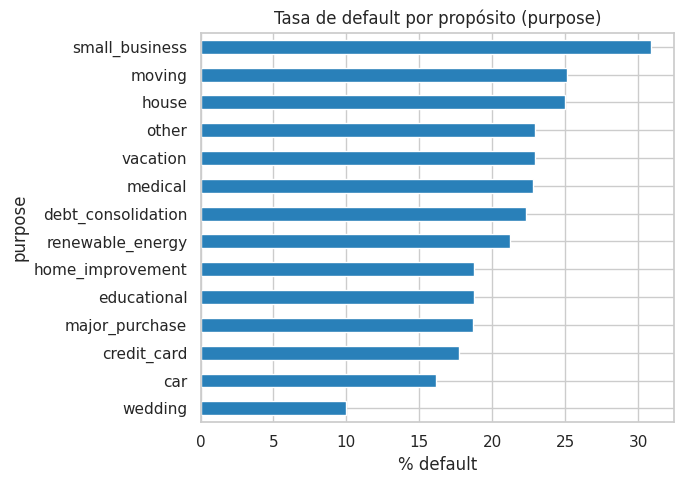

In [34]:
# 3.4 Tasa de default por propósito del préstamo
if "purpose" in df.columns:
    p = (df.groupby("purpose")[TARGET].mean().sort_values()*100)
    fig, ax = plt.subplots(figsize=(7,5))
    p.plot.barh(ax=ax, color="#2980b9")
    ax.set_title("Tasa de default por propósito (purpose)")
    ax.set_xlabel("% default")
    fig.tight_layout(); fig.savefig(FIG/"06_default_by_purpose.png", dpi=120); plt.show()

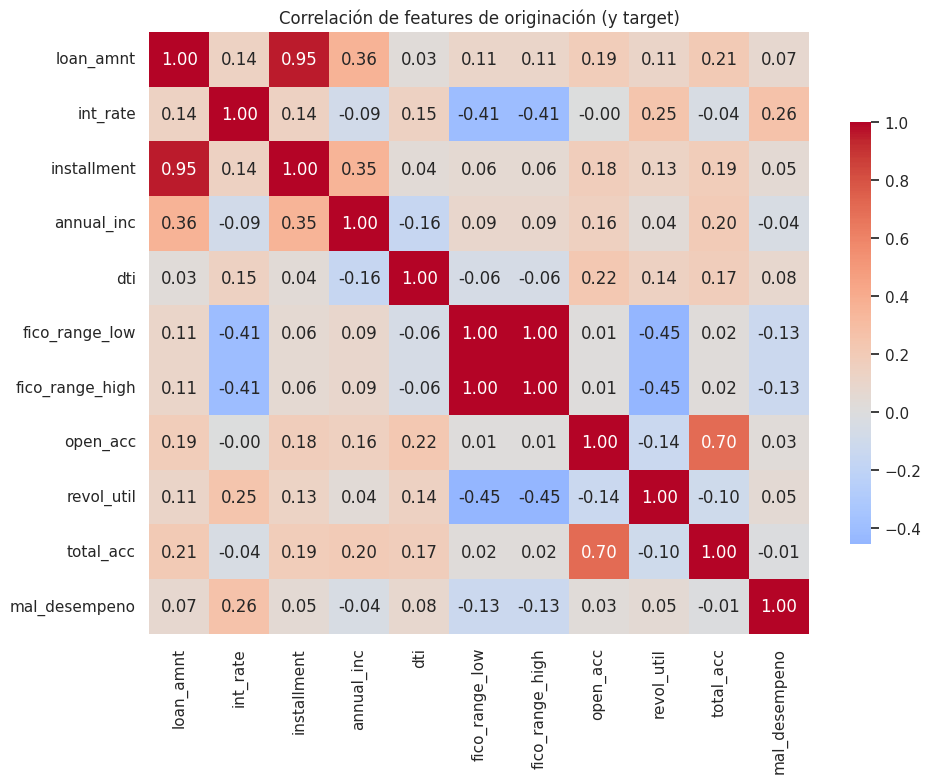

In [35]:
# 3.5 Mapa de correlación entre features numéricas de originación
num_originacion = [
    "loan_amnt", "int_rate", "installment", "annual_inc", "dti",
    "fico_range_low", "fico_range_high", "open_acc", "revol_util", "total_acc",
]
num = [c for c in num_originacion if c in df.columns]

corr = df[num + [TARGET]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            ax=ax, cbar_kws={"shrink":.7})
ax.set_title("Correlación de features de originación (y target)")
fig.tight_layout(); fig.savefig(FIG/"07_corr_heatmap.png", dpi=120); plt.show()

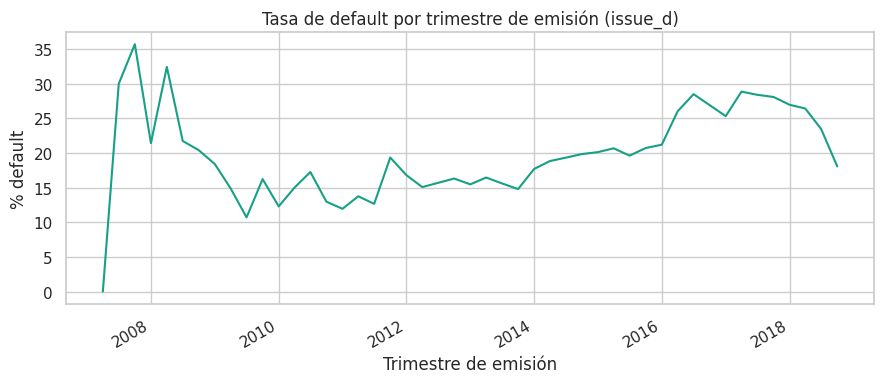

In [36]:
# 3.6 Deriva temporal: tasa de default por trimestre de emisión
iss = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
ts = (df.assign(_m=iss.dt.to_period("Q").dt.to_timestamp())
        .groupby("_m")[TARGET].mean()*100)
fig, ax = plt.subplots(figsize=(9,4))
ts.plot(ax=ax, color="#16a085")
ax.set_title("Tasa de default por trimestre de emisión (issue_d)")
ax.set_ylabel("% default"); ax.set_xlabel("Trimestre de emisión")
fig.tight_layout(); fig.savefig(FIG/"08_default_over_time.png", dpi=120); plt.show()

**Lectura:**
- La tasa de default crece de forma monótona con el `grade`: de **6.8%** en A a
  **49.5%** en G. Es la señal más fuerte y está disponible en la decisión, porque
  Lending Club asigna el grade al originar el préstamo.
- `int_rate` es la variable numérica más correlacionada con el target (**0.26**),
  seguida de FICO (**−0.13**: a mayor FICO, menos default).
- Hay variables redundantes: `fico_range_low` y `fico_range_high` (**1.00**), y
  `loan_amnt` e `installment` (**0.95**). Esto importa para modelos lineales
  (multicolinealidad) y se tratará en la ingeniería de features.
- La tasa de default **varía en el tiempo**: baja de ~20% a ~12–17% entre 2009 y 2013,
  y sube a ~26–29% en 2016–2017. Los trimestres de 2007–2008 son muy ruidosos porque
  hubo pocos préstamos. Esta deriva motiva la partición temporal en lugar de aleatoria.

## 4. Identificación de outliers / registros sospechosos

,annual_inc,dti,revol_util,loan_amnt
count,102157.00,102133.00,102094.00,102159.00
mean,75979.49,18.26,52.17,14461.65
std,59229.33,11.35,24.47,8683.82
min,0.00,0.00,0.00,600.00
1%,18000.00,1.73,1.10,1550.00
25%,45500.00,11.74,33.90,8000.00
50%,65000.00,17.61,52.60,12000.00
75%,90000.00,24.06,71.10,20000.00
99%,250000.00,38.42,98.30,35000.00
max,6500000.00,999.00,145.00,40000.00


Ingresos anuales > 1,000,000: 19
DTI > 60 (posible error): 112


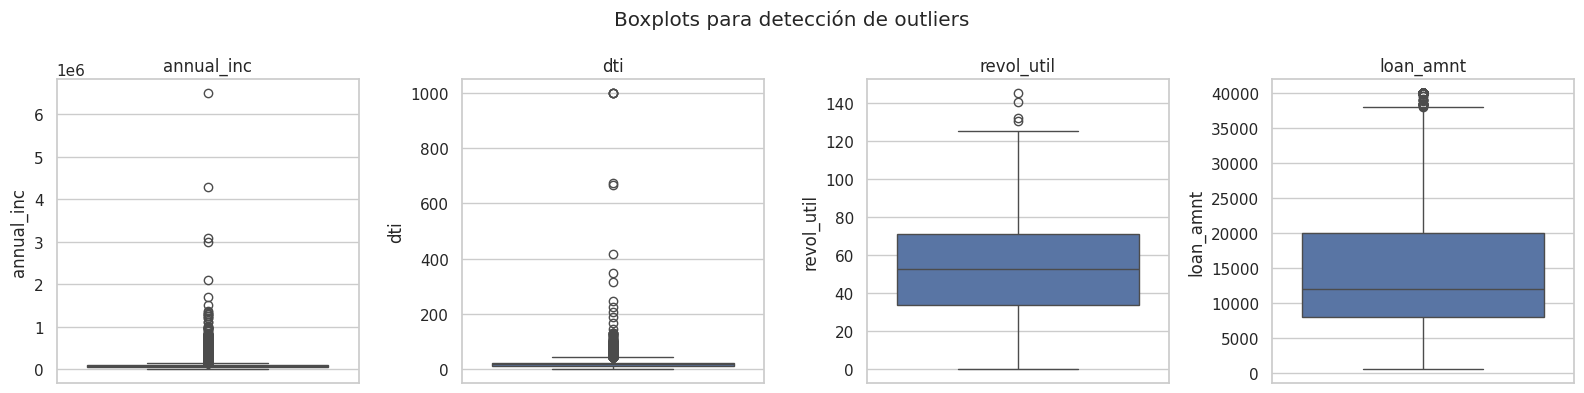

In [37]:
cols = [c for c in ["annual_inc","dti","revol_util","loan_amnt"] if c in df.columns]
display(df[cols].describe(percentiles=[.01,.25,.5,.75,.99]).round(2))

if "annual_inc" in df.columns:
    print("Ingresos anuales > 1,000,000:", int((df['annual_inc']>1_000_000).sum()))
if "dti" in df.columns:
    print("DTI > 60 (posible error):", int((df['dti']>60).sum()))

fig, axes = plt.subplots(1, len(cols), figsize=(4*len(cols),4))
for ax, c in zip(np.atleast_1d(axes), cols):
    sns.boxplot(y=df[c], ax=ax); ax.set_title(c)
fig.suptitle("Boxplots para detección de outliers")
fig.tight_layout(); fig.savefig(FIG/"09_outliers.png", dpi=120); plt.show()

**Lectura:** `annual_inc` tiene colas extremas (ingresos autodeclarados) y
`dti` presenta valores imposibles en algunos registros. En la entrega final se
recortarán/winsorizarán con umbrales justificados, ajustados **solo con train**.

## 5. Discusión inicial: sesgos, leakage y limitaciones

**Leakage (riesgo principal).** El dataset incluye decenas de columnas
generadas *después* de otorgar el crédito: pagos (`total_pymnt`,
`total_rec_prncp`), recuperaciones (`recoveries`), buró actualizado
(`last_fico_range_*`) y acuerdos de liquidación/hardship. Usarlas dispararía las
métricas de forma engañosa. **Control:** la carga usa solo columnas de originación
(lista blanca en `columnas_utiles`), así que las variables de leakage ni siquiera
entran al análisis; `src/features.py` documenta la lista negra (`LEAKAGE_COLUMNS`).
Toda transformación se ajusta solo con train dentro de un `Pipeline`.

**Sesgos.** (1) *Sesgo de selección*: solo vemos préstamos que LC ya **aprobó**;
el modelo no observa a los rechazados, así que estima riesgo condicionado a la
política de aprobación de LC. (2) *Sesgo temporal*: las políticas cambiaron entre
2007 y 2018. (3) *Sesgos sensibles*: variables como `addr_state` pueden correlacionar
con atributos protegidos; se revisará equidad por segmentos en la entrega final.

**Limitaciones.**
- *Sesgo de resolución*: al excluir los préstamos `Current`, los años recientes
  quedan representados sobre todo por préstamos que ya terminaron, muchos por default
  temprano. Por eso la tasa de default en validación (**27.2%**) es mayor que en
  train (**19.4%**).
- Ingresos y empleo son autodeclarados.
- Los faltantes pueden no ser aleatorios.

## 6. Baseline simple ejecutado

Partición **temporal** por `issue_d` (train = préstamos antiguos, validación =
20% más reciente) y dos referencias: clase mayoritaria y **regresión logística**
sin balanceo. El baseline se entrena en la celda siguiente y guarda las métricas
en `outputs/metrics.json`.

Train: 2007-06 a 2016-06  (n=80,746)
Valid: 2016-07 a 2018-12  (n=21,413)
Tasa de default  train=0.194  valid=0.272



,roc_auc,pr_auc,ks,f1,precision,recall,brier
dummy_prior,0.5000,0.2721,0.0000,0.0000,0.0000,0.0000,0.2042
logistic_regression,0.6865,0.4298,0.2705,0.0471,0.5934,0.0245,0.1885


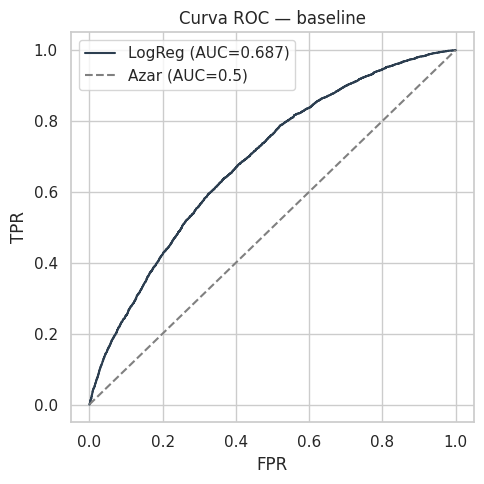

In [38]:
# 6. Baseline: clase mayoritaria vs. regresión logística (partición temporal)
import json
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             brier_score_loss, precision_score, recall_score, f1_score)

data = df.copy()

data["issue_dt"] = pd.to_datetime(data["issue_d"], format="%b-%Y", errors="coerce")
ecl = pd.to_datetime(data["earliest_cr_line"], format="%b-%Y", errors="coerce")
data["credit_hist_months"] = (data["issue_dt"] - ecl).dt.days / 30.44

num_cols = [c for c in ["loan_amnt", "int_rate", "installment", "annual_inc", "dti",
                        "fico_range_low", "fico_range_high", "open_acc", "revol_util",
                        "total_acc", "credit_hist_months", "delinq_2yrs",
                        "inq_last_6mths", "pub_rec", "revol_bal", "pub_rec_bankruptcies"]
            if c in data.columns]
cat_cols = [c for c in ["term", "grade", "sub_grade", "emp_length", "home_ownership",
                        "purpose", "verification_status", "application_type",
                        "initial_list_status"]
            if c in data.columns]

data = data.dropna(subset=["issue_dt"]).sort_values("issue_dt")
cutoff = data["issue_dt"].iloc[int(len(data) * 0.8)]
train = data[data["issue_dt"] < cutoff]
valid = data[data["issue_dt"] >= cutoff]
print(f"Train: {train['issue_dt'].min():%Y-%m} a {train['issue_dt'].max():%Y-%m}  (n={len(train):,})")
print(f"Valid: {valid['issue_dt'].min():%Y-%m} a {valid['issue_dt'].max():%Y-%m}  (n={len(valid):,})")
assert len(train) > 0 and len(valid) > 0, "La muestra no cubre suficientes meses para un split temporal"

X_tr, y_tr = train[num_cols + cat_cols], train[TARGET]
X_va, y_va = valid[num_cols + cat_cols], valid[TARGET]
print(f"Tasa de default  train={y_tr.mean():.3f}  valid={y_va.mean():.3f}\n")

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])
modelos = {
    "dummy_prior": DummyClassifier(strategy="prior"),
    "logistic_regression": Pipeline([("prep", preprocess),
                                     ("clf", LogisticRegression(max_iter=1000,
                                                                random_state=RANDOM_SEED))]),
}

def evaluar(y, p, thr=0.5):
    fpr, tpr, _ = roc_curve(y, p)
    pred = (p >= thr).astype(int)
    return {"roc_auc": roc_auc_score(y, p),
            "pr_auc": average_precision_score(y, p),
            "ks": float(np.max(tpr - fpr)),
            "brier": brier_score_loss(y, p),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0)}

metrics, probas = {}, {}
for nombre, modelo in modelos.items():
    modelo.fit(X_tr, y_tr)
    probas[nombre] = modelo.predict_proba(X_va)[:, 1]
    metrics[nombre] = evaluar(y_va, probas[nombre])

tbl = pd.DataFrame(metrics).T[["roc_auc", "pr_auc", "ks", "f1", "precision", "recall", "brier"]]
display(tbl.round(4))

Path("outputs").mkdir(exist_ok=True)
with open("outputs/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

fpr, tpr, _ = roc_curve(y_va, probas["logistic_regression"])
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(fpr, tpr, color="#2c3e50",
        label=f"LogReg (AUC={metrics['logistic_regression']['roc_auc']:.3f})")
ax.plot([0,1], [0,1], "--", color="gray", label="Azar (AUC=0.5)")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("Curva ROC — baseline")
ax.legend()
fig.tight_layout(); fig.savefig(FIG/"10_roc_baseline.png", dpi=120); plt.show()

### Lectura inicial del resultado

- La regresión logística obtiene **ROC-AUC = 0.687** y **KS = 0.271**, frente a 0.5 y 0
  de la referencia trivial: las variables de originación (sobre todo `grade`/`int_rate`)
  tienen poder predictivo **sin leakage**.
- **PR-AUC = 0.430**, frente a 0.272 de la referencia trivial (su PR-AUC es igual a la
  tasa de default en validación).
- Con umbral 0.5, el **recall es de solo 2.4%** (precisión 59.3%): sin balanceo, el modelo
  casi nunca predice default. El modelo sí ordena bien por riesgo (AUC), pero el umbral
  0.5 no sirve para esta tasa base. El ajuste de umbral y el balanceo se trabajarán en
  la fase de modelado.
- La tasa de default pasa de **19.4%** en train (2007–2016) a **27.2%** en validación
  (2016–2018), lo que confirma la deriva temporal.
- Este resultado es el piso honesto contra el cual se compararán modelos de árboles
  y gradient boosting (≥3 familias), con búsqueda de hiperparámetros bajo validación
  temporal.